# Feature Update Report: Principal Component Analysis (PCA) Integration

**Release:** v0.2.0

## 1. Introduction to the New Feature
While the hierarchical clustermap implemented in `v0.1.0` provides excellent pairwise sample comparisons, it can be beneficial to view the global variance of the dataset in a lower-dimensional geometric space. 

In `v0.2.0`, we introduce **Principal Component Analysis (PCA)**. This dimensionality reduction technique projects the high-dimensional transcriptomic data onto a 2D coordinate system, allowing researchers to quickly spot biological clusters, batch effects, or technical outliers based on the largest axes of variance.

In [1]:
import sys
import pandas as pd

# Append parent directory to path to allow importing from src
sys.path.append("..")

from sample_similarity_explorer.dim_reduction import compute_and_plot_pca

## 2. Load and Preprocess Data
We will use the same **GDS6063** dataset. We must drop missing values before applying PCA, as the algorithm requires complete feature vectors.

In [2]:
# Load the real dataset
data_path = "../data/gds6063_expression.csv"
df = pd.read_csv(data_path, index_col=0)

# Drop rows with NaN values for PCA compatibility
df_clean = df.dropna()
print(f"Data shape after dropping NaNs: {df_clean.shape}")

Data shape after dropping NaNs: (47321, 10)


## 3. Run PCA Visualization
The new `compute_and_plot_pca` function automatically transposes the matrix, scales the features (Z-score normalization), computes the principal components, and generates an annotated scatter plot.

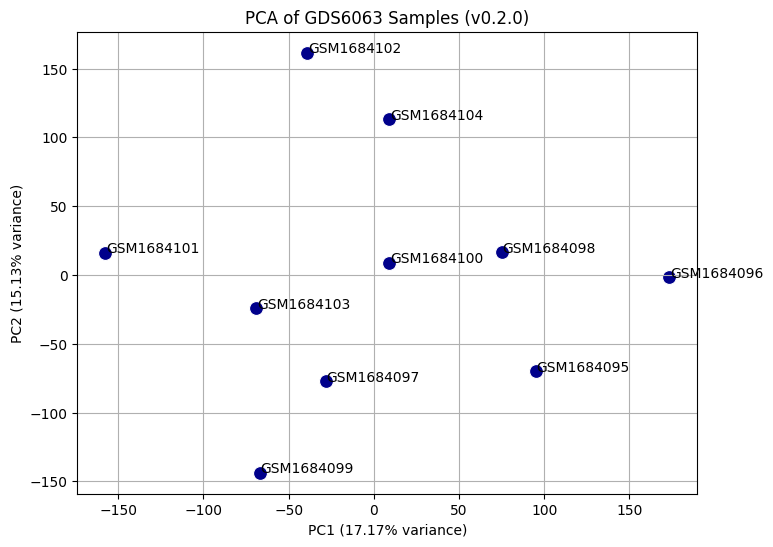

,PC1,PC2,Sample
0,173.273349,-1.644821,GSM1684096
1,74.972807,16.445656,GSM1684098
2,9.119802,8.918145,GSM1684100
3,-39.107003,161.508515,GSM1684102
4,8.862916,113.218379,GSM1684104


In [3]:
# Compute PCA and plot the results
pca_results = compute_and_plot_pca(df_clean, title="PCA of GDS6063 Samples (v0.2.0)")

# Display the raw PCA coordinates
display(pca_results.head())

## 4. Conclusion and Biological Interpretation
**Observation:** The PCA scatter plot successfully projects the 10 samples based on their primary axes of variance.

**Conclusion:** The spatial grouping observed in the PCA plot perfectly complements the results from our Spearman hierarchical clustermap. Samples that showed high correlation scores (e.g., the dark blue blocks in the heatmap) cluster closely together in the PCA space. This dual-perspective approach (correlation + geometric distance) significantly strengthens the robustness of our Quality Control (QC) pipeline.